In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NMVli3YwBR2SldmWnurA")
project = rf.workspace("dock-vdcx1").project("my-first-project-8wzpq")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 90.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-1 in yolov8:: 100%|██████████| 7340/7340 [00:01<00:00, 7225.11it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.info()

model.train(
    data=dataset.location + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,  # reduce to 8 or 4 if you get OOM error
    workers=2,
    device=0,  # use GPU if available
    name="rf_yolo8m_optimized",
    project="/content/yolo_rf_training",
    patience=10,  # early stopping
    augment=True,  # enables data augmentation
    hsv_h=0.015,  # hue augmentation
    hsv_s=0.7,    # saturation
    hsv_v=0.4,    # brightness
    scale=0.5,    # scale variation
    mosaic=1.0,   # keep mosaic on
    mixup=0.2,    # slight mixup for robustness
    degrees=0.1,  # light rotation
    translate=0.1,
    flipud=0.2,
    fliplr=0.5,
    lr0=0.01  # initial learning rate
)

100%|██████████| 49.7M/49.7M [00:00<00:00, 356MB/s]


YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-1/data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rf_yolo8m_optimized, nbs=64, nms=False, opset=None, optimize=False, opt

100%|██████████| 755k/755k [00:00<00:00, 130MB/s]

Overriding model.yaml nc=80 with nc=8

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3780328  ultralytics.nn.modules.head.Detect           [8, [192, 384, 576]]          
Model summary: 169 layers, 25,860,952 parameters, 25,860,936 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


...

                   all        387        854      0.648      0.682      0.698      0.648



50 epochs completed in 1.495 hours.
Optimizer stripped from /content/yolo_rf_training/rf_yolo8m_optimized/weights/last.pt, 52.0MB
Optimizer stripped from /content/yolo_rf_training/rf_yolo8m_optimized/weights/best.pt, 52.0MB

Validating /content/yolo_rf_training/rf_yolo8m_optimized/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:11<00:00,  1.09it/s]


                   all        387        854      0.658       0.69      0.705      0.654
                   Bag        102        145      0.818      0.837      0.861      0.773
                Bottle         55         74      0.756       0.77      0.811      0.776
                   Box         65         78      0.737      0.744      0.764      0.756
                   Cap         65        257      0.694      0.724      0.763      0.684
           Credit Card         67         68      0.573      0.426      0.527      0.503
                   Cup         83        164      0.598      0.622      0.597      0.556
               Cutlery         23         29      0.618      0.759      0.712      0.637
            Toothbrush         29         39      0.468      0.641      0.607      0.546
Speed: 0.2ms preprocess, 23.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/yolo_rf_training/rf_yolo8m_optimized


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79cd43f8cc50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [ ]:
# Validate model on dataset
model.val(data='/content/My-First-Project-1/data.yaml')  # This runs validation and prints metrics


Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1275.0±235.2 MB/s, size: 43.2 KB)


val: Scanning /content/My-First-Project-1/valid/labels.cache... 387 images, 9 backgrounds, 0 corrupt: 100%|██████████| 387/387 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:21<00:00,  1.18it/s]


                   all        387        854      0.657       0.69      0.705      0.653
                   Bag        102        145      0.816      0.834      0.861      0.774
                Bottle         55         74      0.756       0.77      0.812      0.776
                   Box         65         78      0.738      0.744      0.762      0.755
                   Cap         65        257      0.694      0.724      0.762      0.681
           Credit Card         67         68      0.574      0.426      0.527      0.503
                   Cup         83        164      0.598      0.622      0.598      0.558
               Cutlery         23         29      0.619      0.759      0.712       0.63
            Toothbrush         29         39       0.46      0.641      0.607      0.548
Speed: 1.5ms preprocess, 48.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/yolo_rf_training/rf_yolo8m_optimized3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79cebae33390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,


image 1/1 /content/My-First-Project-1/test/images/00000783_jpg.rf.0c868876d5cfb757edcc3ccfab489e30.jpg: 640x640 1 Bag, 37.0ms
Speed: 2.3ms preprocess, 37.0ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


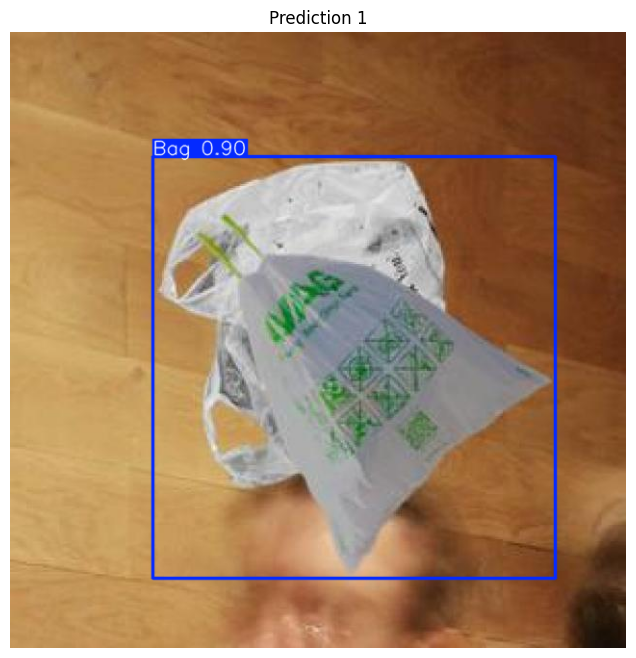


image 1/1 /content/My-First-Project-1/test/images/-49-_jpg.rf.7f9ed11356e3ed13f2a4fffcc95cbf0f.jpg: 640x640 1 Bag, 37.1ms
Speed: 2.3ms preprocess, 37.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


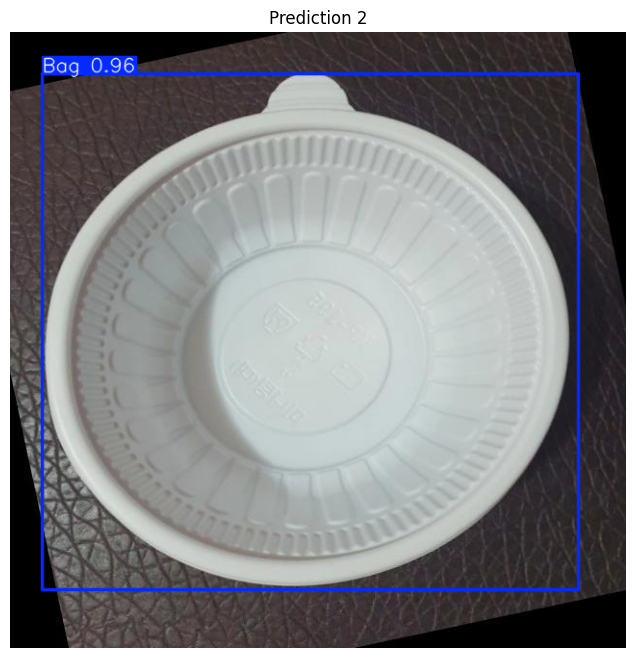


image 1/1 /content/My-First-Project-1/test/images/00000771_jpg.rf.6d3a7c269043d041ff58fd03dcf9669c.jpg: 640x640 1 Bag, 37.1ms
Speed: 3.2ms preprocess, 37.1ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


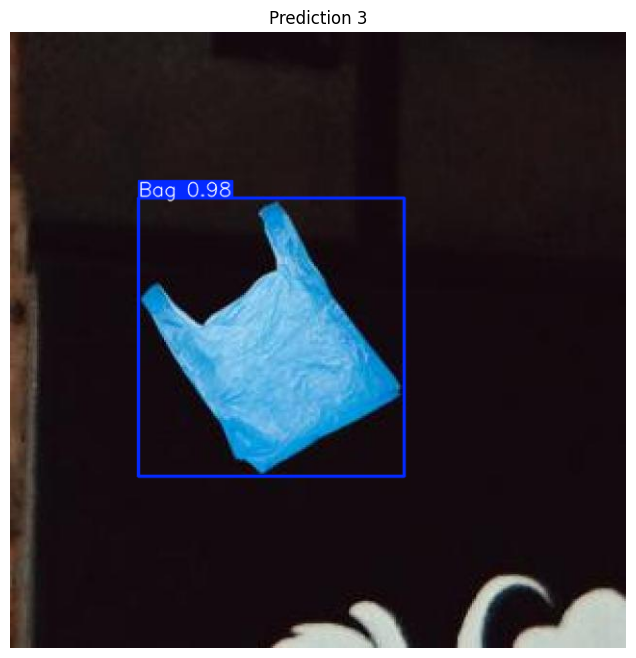


image 1/1 /content/My-First-Project-1/test/images/23_png.rf.64a09efe14c2bbfee74bfaef32b2bbc9.jpg: 640x640 1 Bottle, 37.2ms
Speed: 2.7ms preprocess, 37.2ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


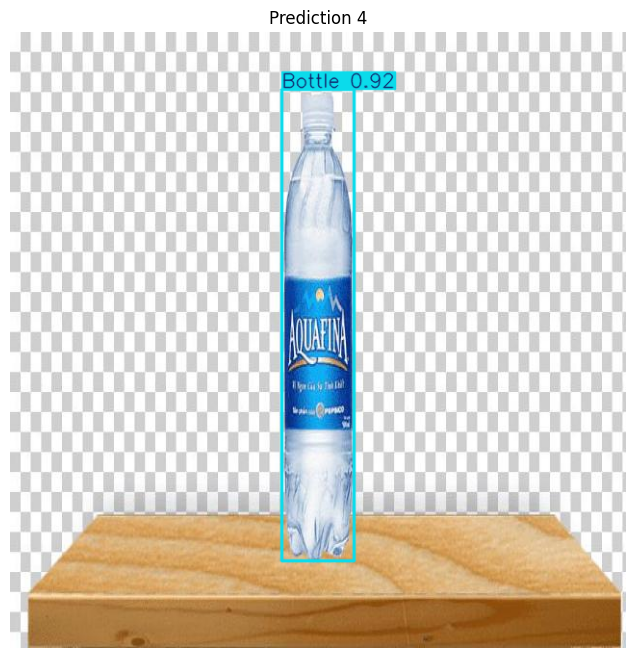


image 1/1 /content/My-First-Project-1/test/images/16_jpg.rf.d2c203f53b0a0aba63e77c0b75ad37c1.jpg: 640x640 2 Bottles, 1 Cup, 37.1ms
Speed: 2.7ms preprocess, 37.1ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 640)


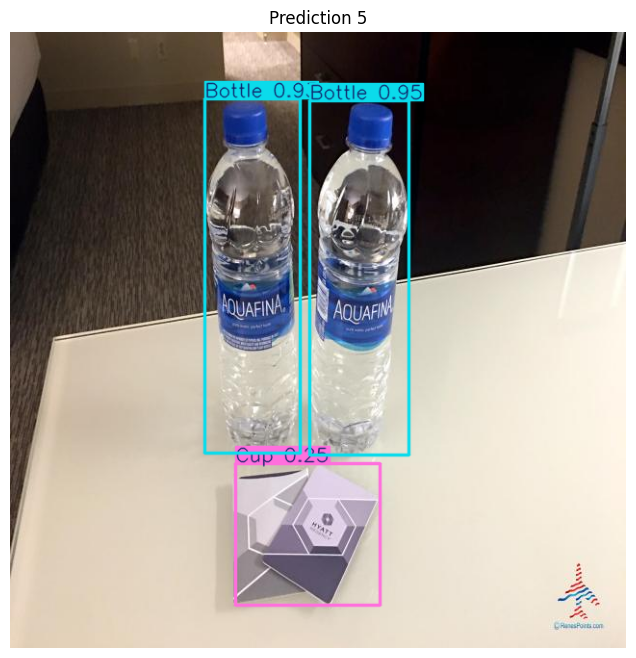


image 1/1 /content/My-First-Project-1/test/images/spoon_178_jpg.rf.d363c48a2ea9443d83bdc94aa49a84c4.jpg: 640x640 1 Bag, 39.3ms
Speed: 2.9ms preprocess, 39.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


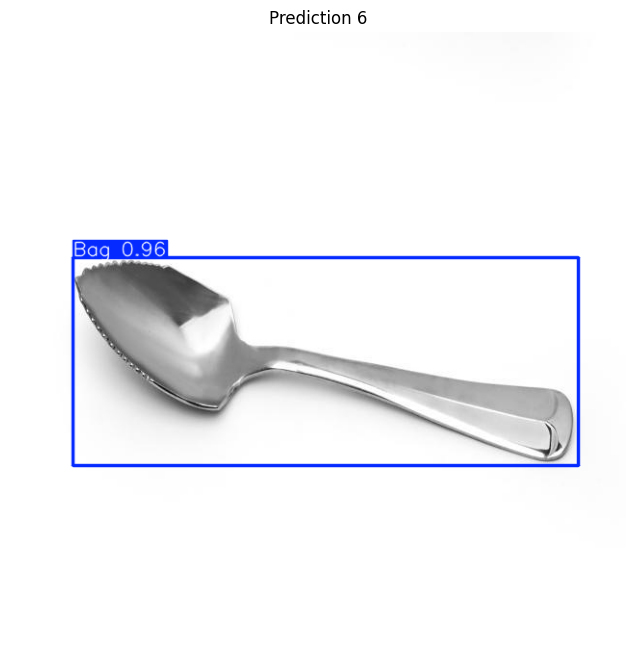


image 1/1 /content/My-First-Project-1/test/images/spoon_173_jpg.rf.1560ef023b46934b247ef6887bbea393.jpg: 640x640 1 Cap, 1 Credit Card, 37.1ms
Speed: 2.9ms preprocess, 37.1ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


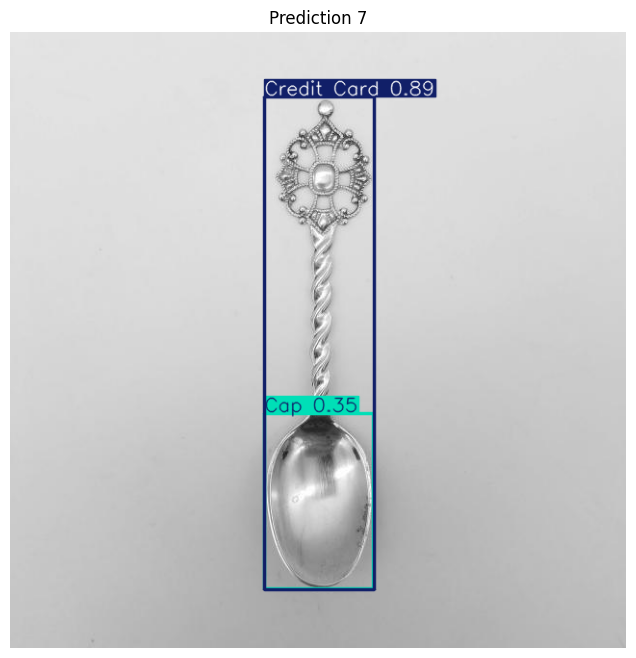


image 1/1 /content/My-First-Project-1/test/images/00000719_jpg.rf.468a5ea0ea64c64562525b19b1cc52ba.jpg: 640x640 (no detections), 41.3ms
Speed: 5.1ms preprocess, 41.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


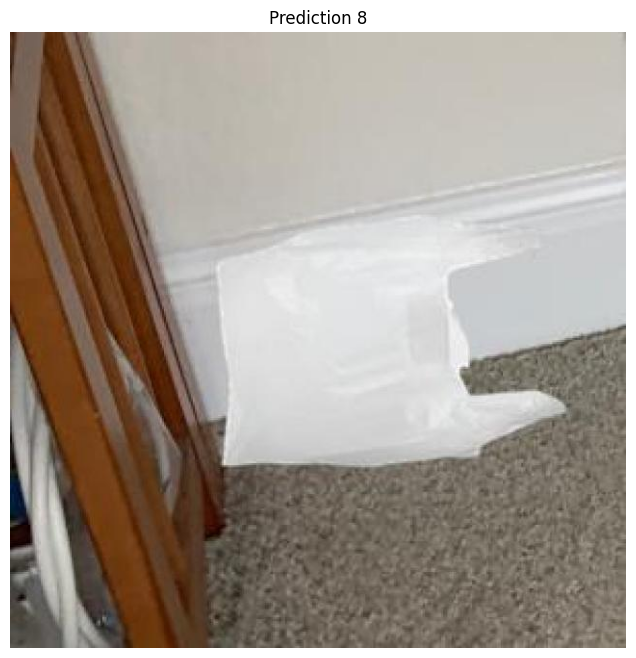


image 1/1 /content/My-First-Project-1/test/images/spoon_101_jpg.rf.03d658df33fa80db9ec65c61ce7d30fa.jpg: 640x640 1 Cap, 37.1ms
Speed: 3.3ms preprocess, 37.1ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


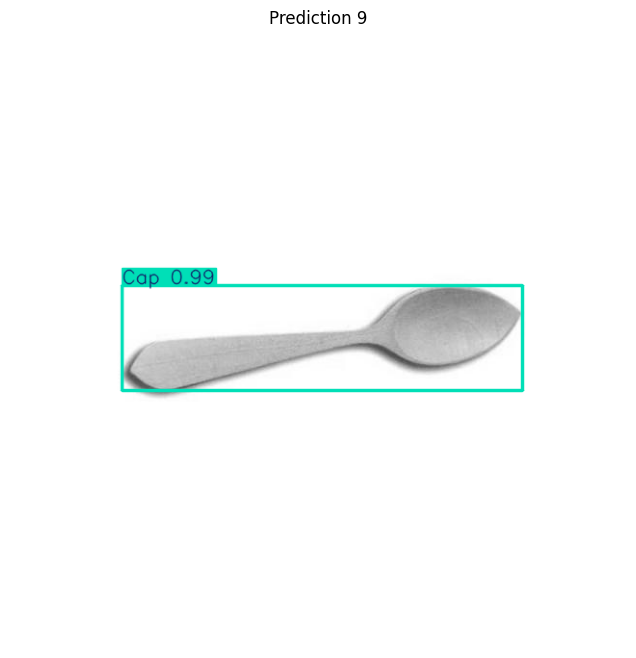


image 1/1 /content/My-First-Project-1/test/images/00000767_jpg.rf.bc9466188005ffe11e81ad6547ab77a1.jpg: 640x640 1 Bag, 37.1ms
Speed: 2.6ms preprocess, 37.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


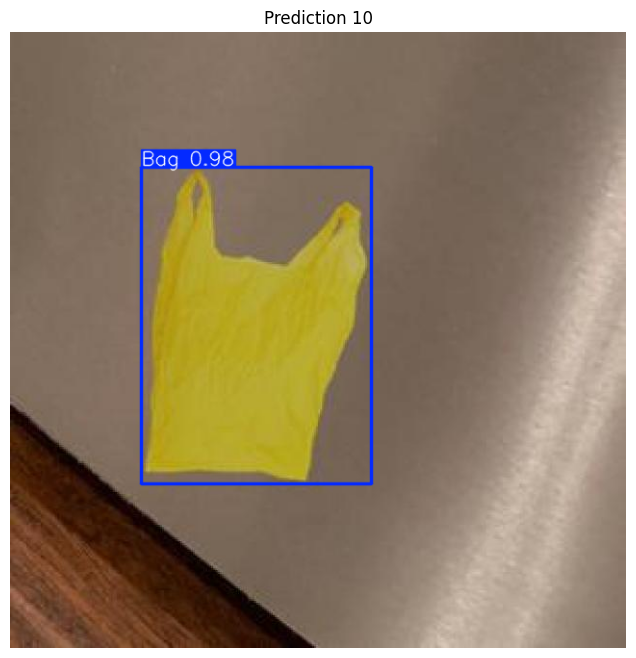

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import random

# ======= CONFIGURE ========
MODEL_PATH = '/content/yolo_rf_training/rf_yolo8m_optimized/weights/best.pt'  # Change this if your model path is different
TEST_IMAGE_DIR = '/content/My-First-Project-1/test/images'            # Folder with test images
N_IMAGES = 10
IMAGE_SIZE = 640                                 # Input size for inference
CONFIDENCE_THRESHOLD = 0.25                      # Adjust as needed
# ==========================

# Load model
model = YOLO(MODEL_PATH)

# List of test images
test_images = [os.path.join(TEST_IMAGE_DIR, f) for f in os.listdir(TEST_IMAGE_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Pick 10 random images to visualize
sample_images = random.sample(test_images, min(N_IMAGES, len(test_images)))

# Predict and visualize
for i, image_path in enumerate(sample_images):
    results = model.predict(source=image_path, conf=CONFIDENCE_THRESHOLD, imgsz=IMAGE_SIZE, show=False, save=False)

    # Get image with bounding boxes
    img_with_boxes = results[0].plot()  # Returns numpy array with boxes drawn

    # Display image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Prediction {i+1}")
    plt.show()
